In [50]:
#Importing Libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from matplotlib import style 


In [33]:
#Importing the dataset
df = pd.read_csv("Data/insurance.csv")


In [34]:
#EDA: Exploratory Data Analysis starts from here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [35]:
df.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [37]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [38]:
#Data Preprocessing by Manually Encoding the Categorical Data
df["sex"] = df["sex"].apply({"male":0, "female":1}.get)
df["smoker"] = df["smoker"].apply({"yes":1, "no":0}.get)
df["region"] = df["region"].apply({"southeast":0, "southwest":1, "northeast":2, "northwest":3}.get)

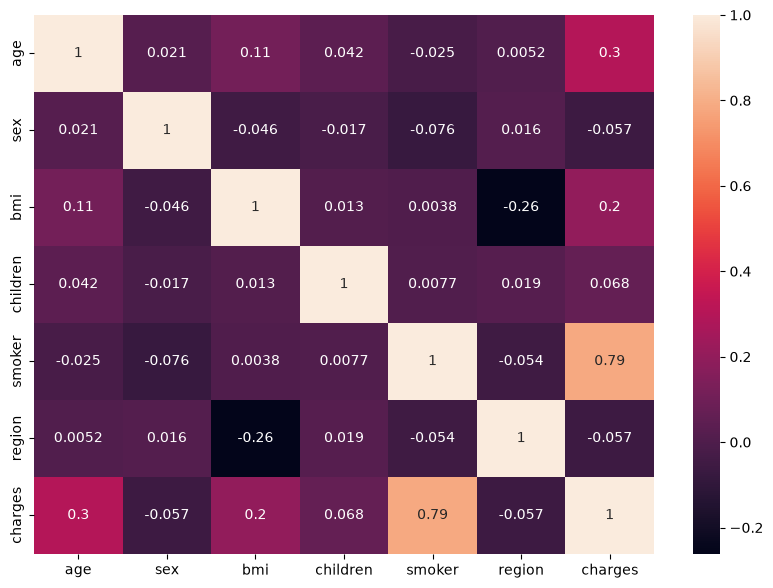

In [40]:
#Correlation Matrix to find the correlation between the features
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [42]:
#Splitting the dataset into independent and dependent features
x = df.drop("charges", axis=1)
y = df["charges"]

In [ ]:
#Splitting the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Training set size: (1070, 6)
Testing set size: (268, 6)


In [ ]:
#Training the Linear Regression Model by fitting the training data
linreg = LinearRegression()
linreg.fit(x_train, y_train)
pred = linreg.predict(x_test)

In [ ]:
#Evaluating the model's performance using Mean Squared Error, R-squared, and Mean Absolute Error metrics
print("Mean Squared Error:", mean_squared_error(y_test, pred))
print("R-squared:", r2_score(y_test, pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, pred)))    

Mean Squared Error: 33685623.354144424
R-squared: 0.783021587162344
Mean Absolute Error: 4190.220190137915
Root Mean Squared Error: 5803.931715151758


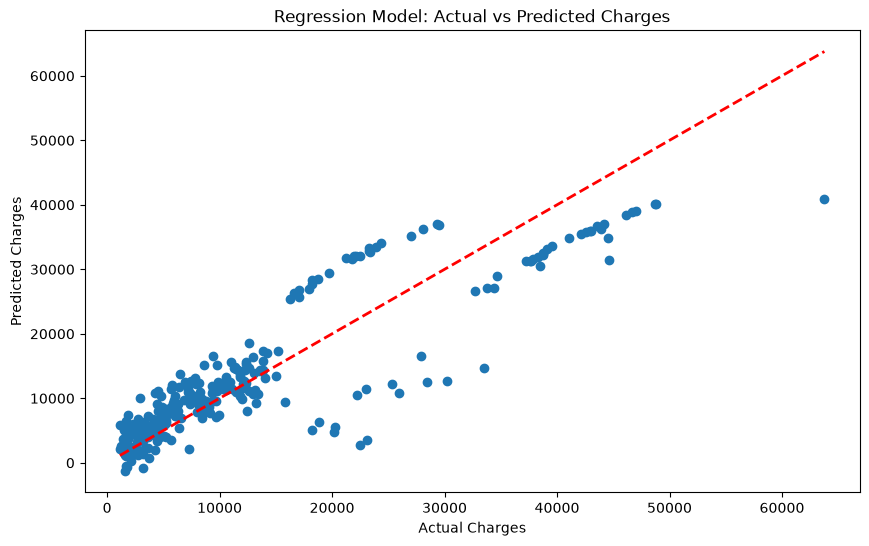

In [54]:
#Plotting the Actual vs Predicted Charges to visualize the model's performance
plt.figure(figsize=(10,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2,label='Perfect Prediction')
plt.title("Regression Model: Actual vs Predicted Charges")
plt.show()

In [59]:
data = {"age": [30], "sex": [1], "bmi": [25.0], "children": [2], "smoker": [0], "region": [1]}
index = [0]
check_df = pd.DataFrame(data, index)
result = linreg.predict(check_df)
print("Predicted Charges for the new customer:", result)

Predicted Charges for the new customer: [4523.45544645]


# 📚 Key Learnings

- Understood the complete workflow of a Machine Learning project.
- Performed Exploratory Data Analysis (EDA) using statistical summaries and visualizations.
- Applied categorical feature encoding to prepare the data for model training.
- Separated the dataset into feature matrix (`X`) and target variable (`y`).
- Trained a Linear Regression model using Scikit-learn.
- Evaluated model performance using MAE, MSE, RMSE, and R² Score.
- Visualized prediction performance using an Actual vs Predicted scatter plot.
- Predicted insurance charges for new customer data using the trained model.